# SINDy Exploration

In [ ]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

project_root = Path.cwd().resolve().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.build_library import build_library
from src.compute_derivatives import estimate_derivatives
from src.simulate_lorenz import save_lorenz_data, simulate_lorenz
from src.simulate_pendulum import save_pendulum_data, simulate_damped_pendulum
from src.sindy_regression import fit_sindy, format_equations, predict_derivatives

## Lorenz

In [ ]:
lorenz_df = simulate_lorenz(t_max=25.0, dt=0.01)
save_lorenz_data(lorenz_df, project_root / "data" / "lorenz_data.csv")
lorenz_derivatives = estimate_derivatives(lorenz_df, ["x", "y", "z"])
lorenz_library, lorenz_terms = build_library(lorenz_df, ["x", "y", "z"], max_degree=2)
lorenz_coefficients = fit_sindy(
    lorenz_library,
    lorenz_derivatives,
    ["x_dot", "y_dot", "z_dot"],
    threshold=0.05,
    max_iterations=10,
)

lorenz_df.head()

In [ ]:
lorenz_coefficients.round(3)

In [ ]:
for equation in format_equations(lorenz_coefficients, precision=3):
    print(equation)

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
for ax, column in zip(axes, ["x", "y", "z"]):
    ax.plot(lorenz_df["t"], lorenz_df[column])
    ax.set_ylabel(column)
axes[-1].set_xlabel("t")
plt.tight_layout()
plt.show()

In [ ]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot(lorenz_df["x"], lorenz_df["y"], lorenz_df["z"], linewidth=0.8)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
plt.tight_layout()
plt.show()

## Damped Pendulum

In [ ]:
pendulum_df = simulate_damped_pendulum(t_max=20.0, dt=0.01, damping=0.2)
save_pendulum_data(pendulum_df, project_root / "data" / "pendulum_data.csv")
pendulum_derivatives = estimate_derivatives(pendulum_df, ["theta", "omega"])
pendulum_library, pendulum_terms = build_library(
    pendulum_df,
    ["theta", "omega"],
    max_degree=2,
    custom_terms={"theta": {"sin": np.sin}},
)
pendulum_coefficients = fit_sindy(
    pendulum_library,
    pendulum_derivatives,
    ["theta_dot", "omega_dot"],
    threshold=0.05,
    max_iterations=10,
)

pendulum_df.head()

In [ ]:
pendulum_coefficients.round(3)

In [ ]:
for equation in format_equations(pendulum_coefficients, precision=3):
    print(equation)

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
for ax, column in zip(axes, ["theta", "omega"]):
    ax.plot(pendulum_df["t"], pendulum_df[column])
    ax.set_ylabel(column)
axes[-1].set_xlabel("t")
plt.tight_layout()
plt.show()

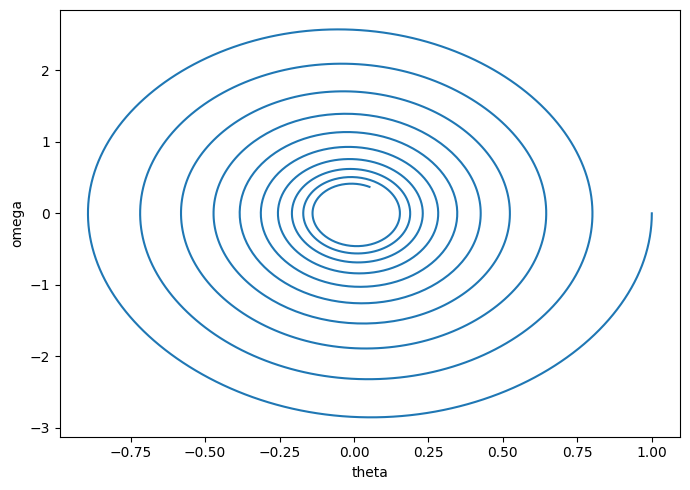

In [11]:
plt.figure(figsize=(7, 5))
plt.plot(pendulum_df["theta"], pendulum_df["omega"])
plt.xlabel("theta")
plt.ylabel("omega")
plt.tight_layout()
plt.show()

### Pendulum Validation

In [10]:
pendulum_predicted_derivatives = predict_derivatives(
    pendulum_library,
    pendulum_coefficients,
)

for target in ["theta_dot", "omega_dot"]:
    rmse = np.sqrt(
        np.mean(
            (
                pendulum_derivatives[target].to_numpy()
                - pendulum_predicted_derivatives[target].to_numpy()
            ) ** 2
        )
    )
    print(f"{target} RMSE: {rmse:.6f}")

theta_dot RMSE: 0.001359
omega_dot RMSE: 0.005695


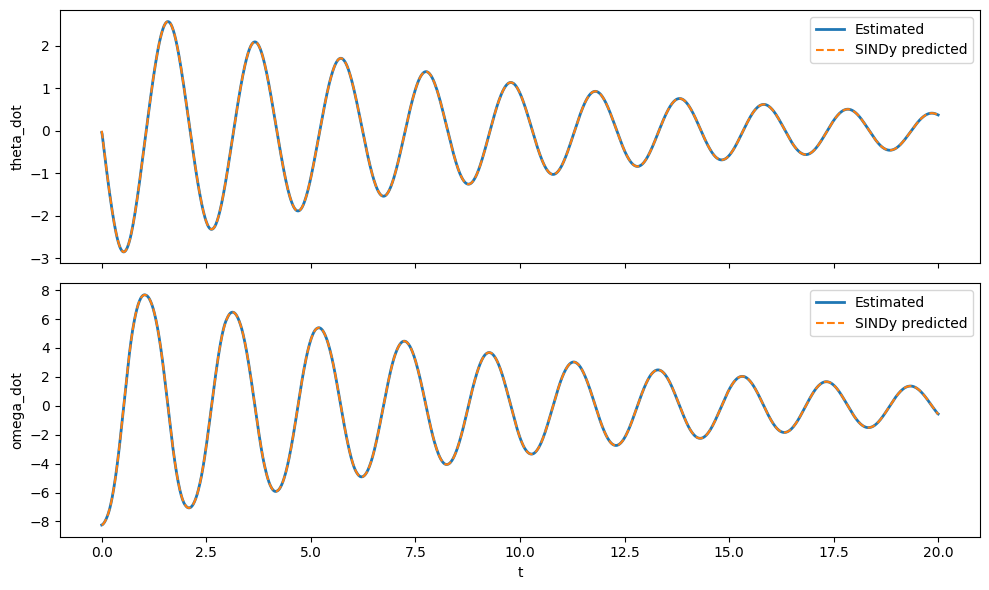

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
for ax, target in zip(axes, ["theta_dot", "omega_dot"]):
    ax.plot(
        pendulum_df["t"],
        pendulum_derivatives[target],
        label="Estimated",
        linewidth=2,
    )
    ax.plot(
        pendulum_df["t"],
        pendulum_predicted_derivatives[target],
        label="SINDy predicted",
        linestyle="--",
    )
    ax.set_ylabel(target)
    ax.legend()

axes[-1].set_xlabel("t")
plt.tight_layout()
plt.show()